In [4]:
%%writefile sort.cpp

#include <iostream>
#include <omp.h>
#include <vector>
#include <cstdlib>
#include <cstdio>
#include <ctime>

using namespace std;

#define TESTS 6
int N_values[TESTS] = {100, 300, 500, 700, 900, 1000};

// ================= UTILITY =================
void generateArray(vector<int> &arr, int N) {
    for (int i = 0; i < N; i++)
        arr[i] = rand() % 10000;
}

void copyArray(vector<int> &src, vector<int> &dest, int N) {
    for (int i = 0; i < N; i++)
        dest[i] = src[i];
}

// ================= BUBBLE SORT =================
void seq_bubble(vector<int> &arr, int N) {
    for (int i = 0; i < N - 1; i++)
        for (int j = 0; j < N - i - 1; j++)
            if (arr[j] > arr[j + 1])
                swap(arr[j], arr[j + 1]);
}


void par_bubble(vector<int> &arr, int N) {

    for (int phase = 0; phase < N; phase++) {

        // ================= EVEN PHASE =================
        if (phase % 2 == 0) {

            #pragma omp parallel for
            for (int i = 0; i < N - 1; i += 2) {
                if (arr[i] > arr[i + 1]) {
                    swap(arr[i], arr[i + 1]);
                }
            }

        }
        // ================= ODD PHASE =================
        else {

            #pragma omp parallel for
            for (int i = 1; i < N - 1; i += 2) {
                if (arr[i] > arr[i + 1]) {
                    swap(arr[i], arr[i + 1]);
                }
            }
        }
    }
}


// ================= MAIN =================
int main() {

    srand(time(NULL));
    int cores = omp_get_max_threads();
    FILE *bubble_f = fopen("bubble_output.txt", "w");

    // ✅ Added COST column
    fprintf(bubble_f, "N,SEQ,PAR,SPEEDUP,EFFICIENCY,COST,CORES\n");

    for (int t = 0; t < TESTS; t++) {

        int N = N_values[t];
        vector<int> arr(N), temp(N);

        generateArray(arr, N);

        double seq, par, speed, eff, cost;

        cout << "\n============================\n";
        cout << "N = " << N << endl;

        // ===== BUBBLE =====
        copyArray(arr, temp, N);
        seq = omp_get_wtime();
        seq_bubble(temp, N);
        seq = omp_get_wtime() - seq;

        copyArray(arr, temp, N);
        par = omp_get_wtime();
        par_bubble(temp, N);
        par = omp_get_wtime() - par;

        speed = seq / par;
        eff = speed / cores;

        cost = par * cores;

        cout << "BUBBLE -> "
             << "Seq=" << seq
             << " Par=" << par
             << " Speedup=" << speed
             << " Efficiency=" << eff
             << " Cost=" << cost << endl;

        fprintf(bubble_f, "%d,%lf,%lf,%lf,%lf,%lf,%d\n",
                N, seq, par, speed, eff, cost, cores);
    }
    fclose(bubble_f);

    cout << "\nResults saved.\n";
    return 0;
}

Overwriting sort.cpp


In [5]:
!g++ -fopenmp sort.cpp -o sort
!./sort


N = 100
BUBBLE -> Seq=8.3268e-05 Par=0.000182783 Speedup=0.455557 Efficiency=0.227778 Cost=0.000365566

N = 300
BUBBLE -> Seq=0.000730653 Par=0.000661608 Speedup=1.10436 Efficiency=0.55218 Cost=0.00132322

N = 500
BUBBLE -> Seq=0.00199052 Par=0.00159777 Speedup=1.24582 Efficiency=0.622908 Cost=0.00319553

N = 700
BUBBLE -> Seq=0.00390812 Par=0.00295168 Speedup=1.32403 Efficiency=0.662017 Cost=0.00590335

N = 900
BUBBLE -> Seq=0.0067316 Par=0.00532556 Speedup=1.26402 Efficiency=0.632009 Cost=0.0106511

N = 1000
BUBBLE -> Seq=0.00875745 Par=0.00648119 Speedup=1.35121 Efficiency=0.675605 Cost=0.0129624

Results saved.


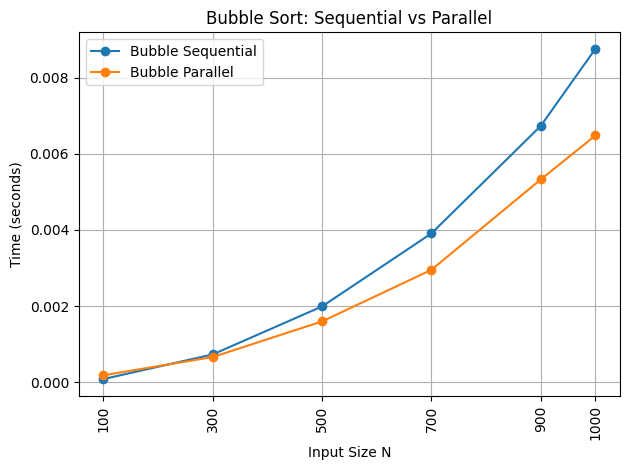

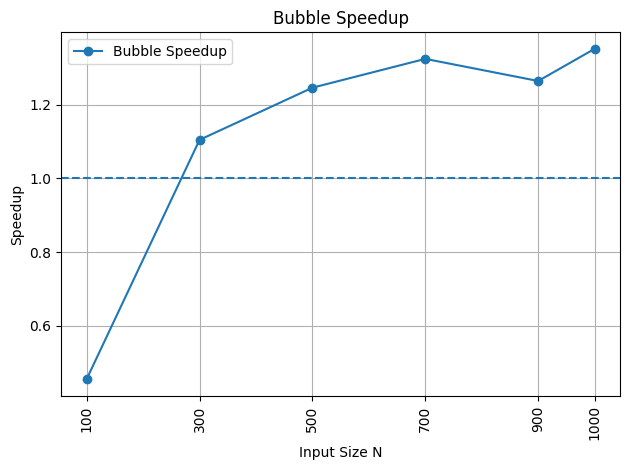

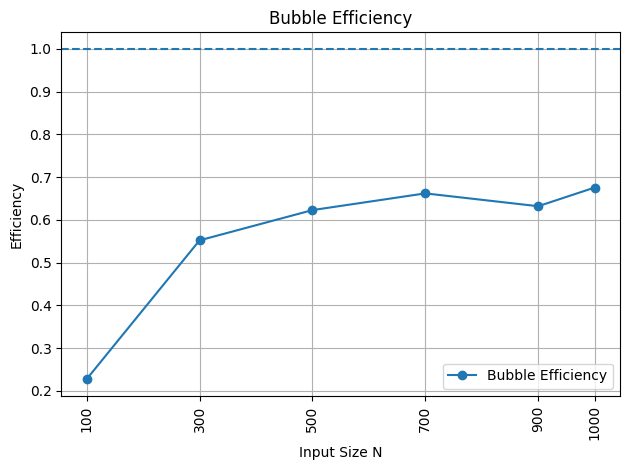

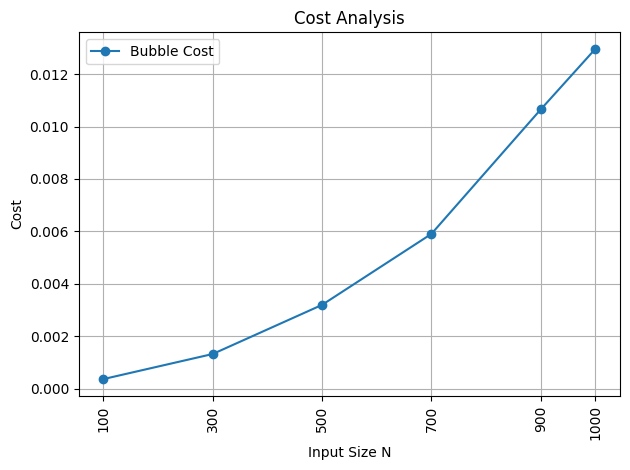

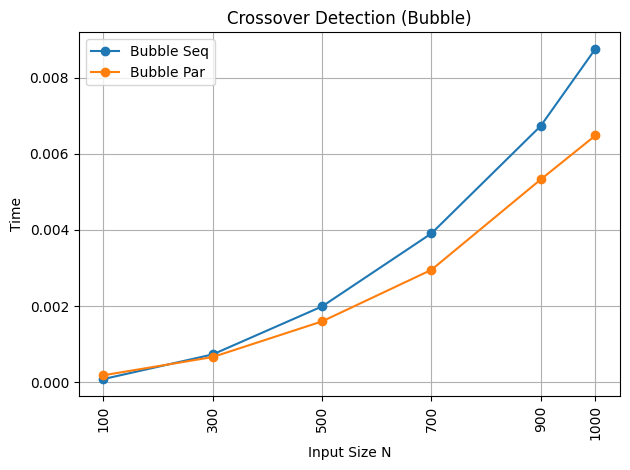

Bubble crossover near N = 300


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ================= BUBBLE DATA =================
bubble_df = pd.read_csv("bubble_output.txt")

N = bubble_df["N"].values

bubble_seq = bubble_df["SEQ"].values
bubble_par = bubble_df["PAR"].values
bubble_speed = bubble_df["SPEEDUP"].values
bubble_cost = bubble_df["COST"].values


CORES = bubble_df["CORES"][0]
bubble_eff = bubble_speed / CORES



# ================= BUBBLE TIME =================
plt.figure()

plt.plot(N, bubble_seq, marker='o', label="Bubble Sequential")
plt.plot(N, bubble_par, marker='o', label="Bubble Parallel")

plt.xlabel("Input Size N")
plt.ylabel("Time (seconds)")
plt.title("Bubble Sort: Sequential vs Parallel")

plt.xticks(N, rotation=90)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# ================= BUBBLE SPEEDUP =================
plt.figure()

plt.plot(N, bubble_speed, marker='o', label="Bubble Speedup")
plt.axhline(y=1, linestyle='--')

plt.xlabel("Input Size N")
plt.ylabel("Speedup")
plt.title("Bubble Speedup")

plt.xticks(N, rotation=90)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()




# ================= BUBBLE EFFICIENCY =================
plt.figure()

plt.plot(N, bubble_eff, marker='o', label="Bubble Efficiency")
plt.axhline(y=1, linestyle='--')

plt.xlabel("Input Size N")
plt.ylabel("Efficiency")
plt.title("Bubble Efficiency")

plt.xticks(N, rotation=90)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# ================= COST GRAPH =================
plt.figure()
plt.plot(N, bubble_cost, marker='o', label="Bubble Cost")

plt.xlabel("Input Size N")
plt.ylabel("Cost")
plt.title("Cost Analysis")

plt.xticks(N, rotation=90)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()




# ================= CROSSOVER (BUBBLE) =================
plt.figure()

plt.plot(N, bubble_seq, marker='o', label="Bubble Seq")
plt.plot(N, bubble_par, marker='o', label="Bubble Par")

plt.xlabel("Input Size N")
plt.ylabel("Time")
plt.title("Crossover Detection (Bubble)")

plt.xticks(N, rotation=90)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

idx = np.argmin(np.abs(bubble_seq - bubble_par))
print("Bubble crossover near N =", N[idx])